### Loss YOLOv11 Plots

#### Side to side plots to figure out the scale

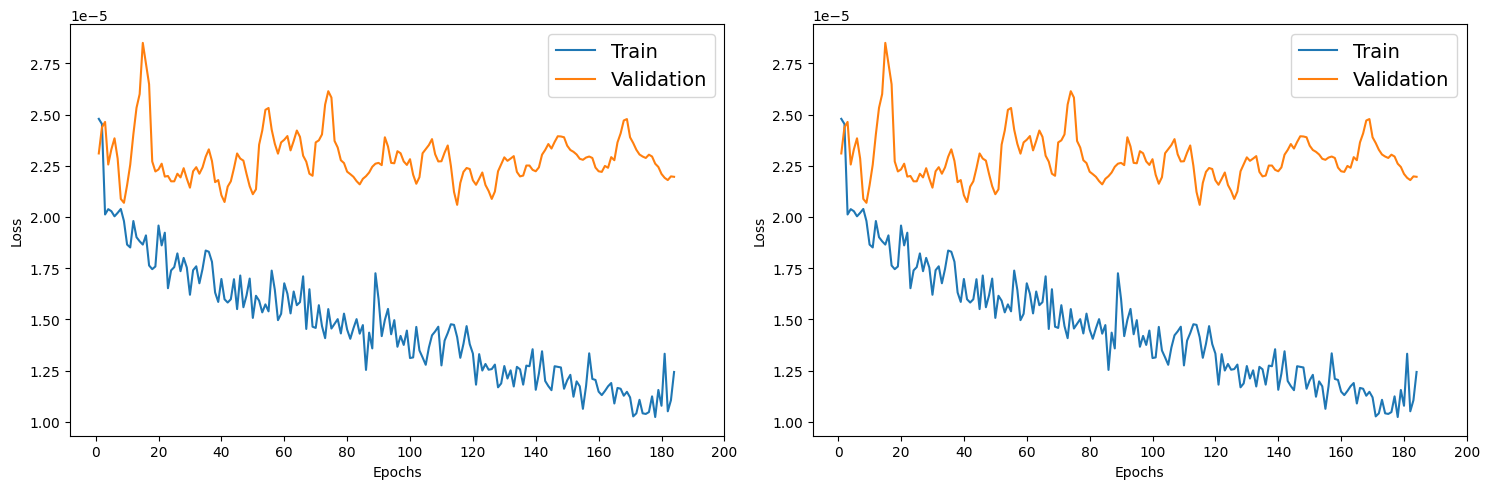

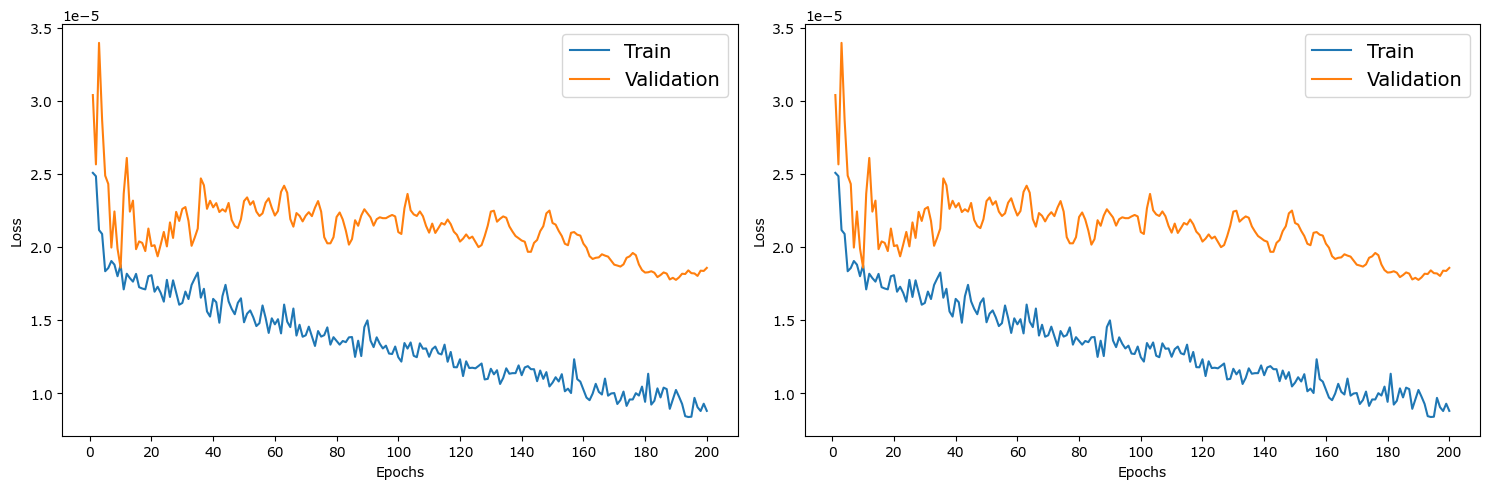

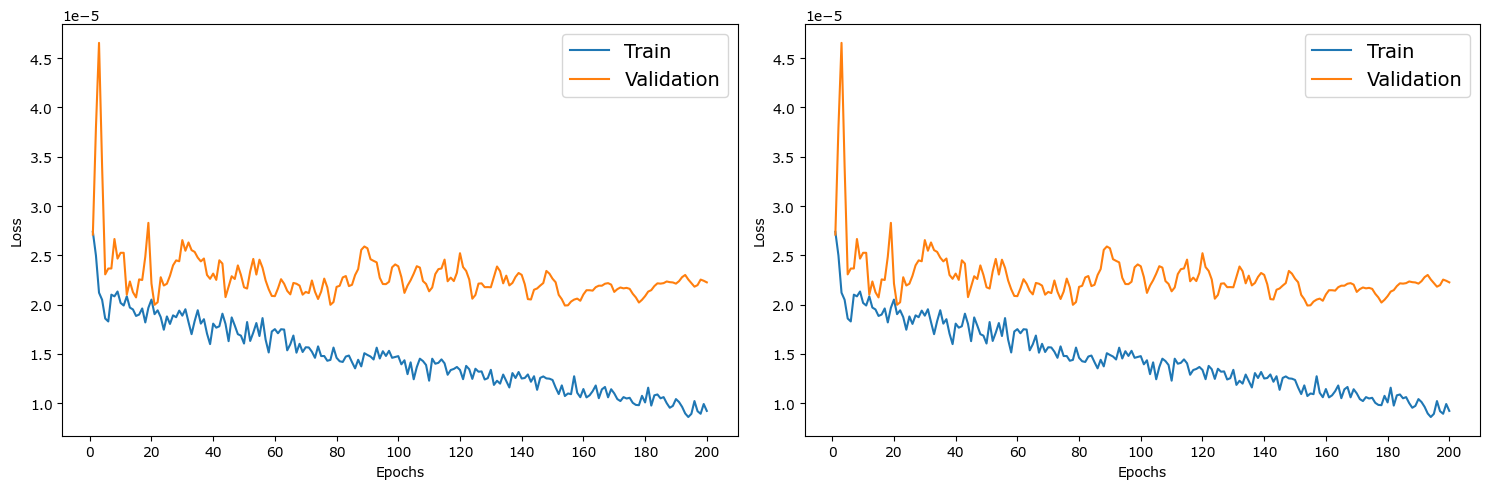

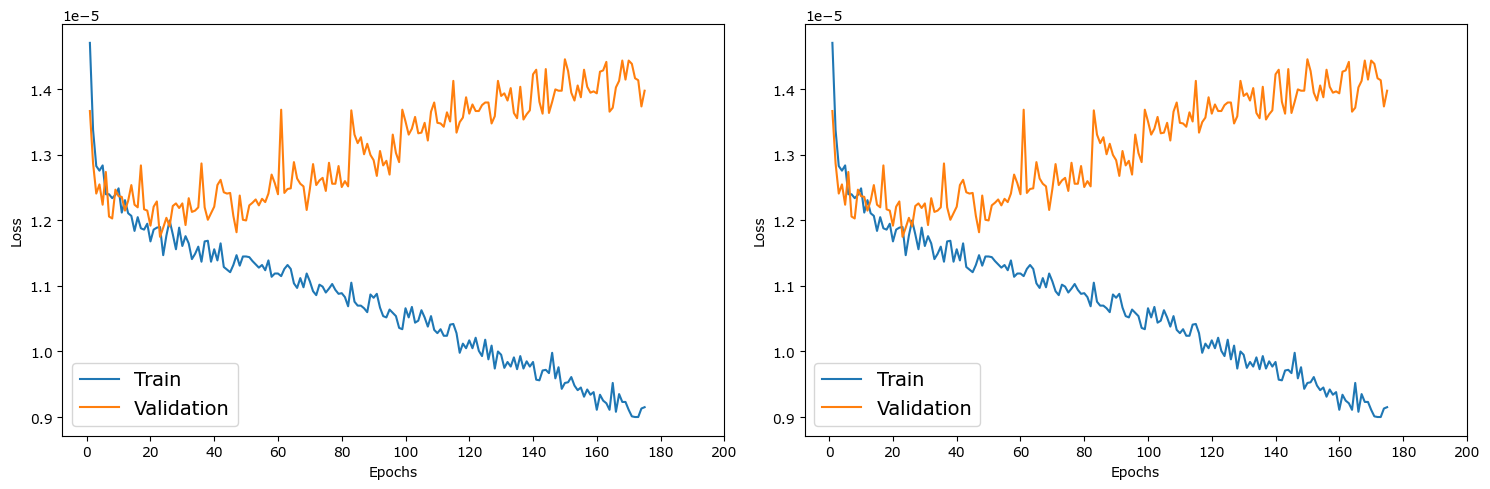

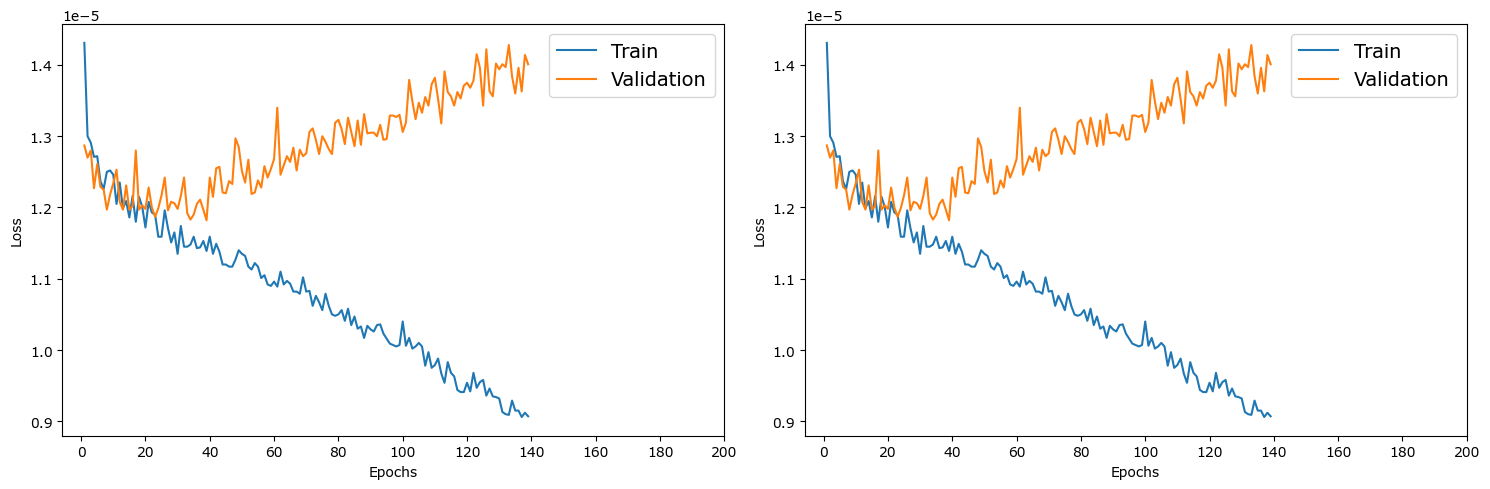

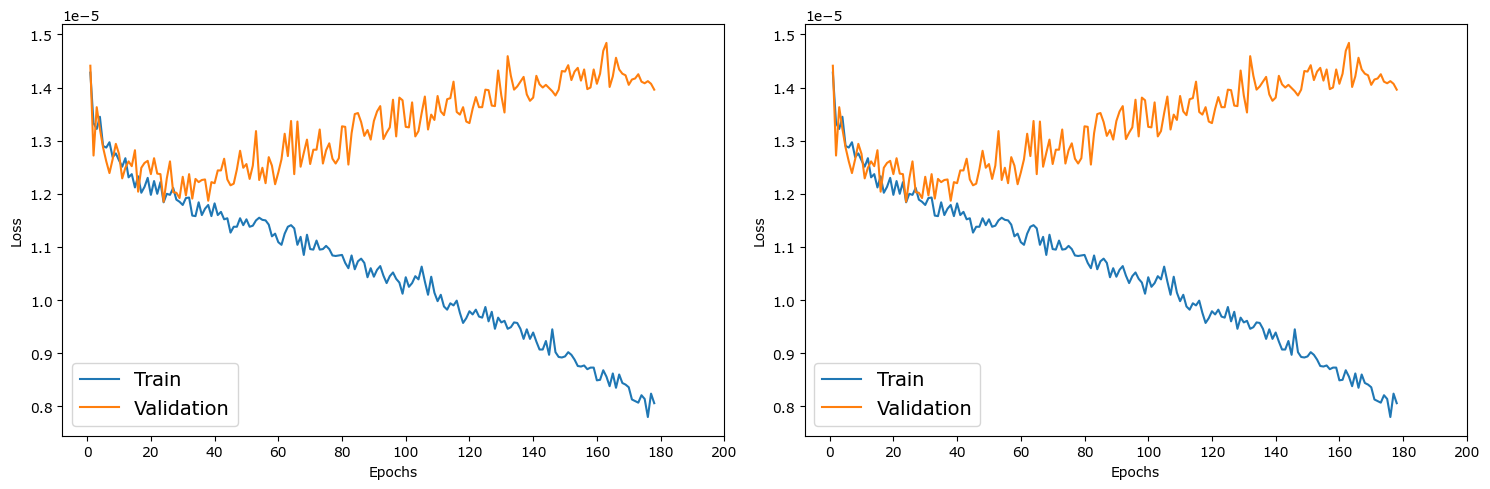

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def graph_plot(file_path, output_path, id):
    epochs = []
    train_cl = []
    val_cl = []
    epochs_i = []
    train_cl_i = []
    val_cl_i = []

    with open(file_path, 'r') as file:
        next(file)
        for line in file:
            # Dividir la línea en elementos usando comas como separadores
            elements = line.strip().split(',')

            # Agregar cada elemento a la lista correspondiente
            epochs.append(int(elements[0]))
            div_train = float(elements[2])
            div_val = float(elements[9])
            train_cl.append(div_train/1000)
            val_cl.append(div_val/1000)

    for i in range(0, len(epochs)):
        epochs_i.append(epochs[i])
        train_cl_i.append(train_cl[i])
        val_cl_i.append(val_cl[i])

    fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
    axs[0].plot(epochs, train_cl, label='Train')
    axs[0].plot(epochs, val_cl, label='Validation')
    axs[0].set_xlabel('Epochs')
    axs[0].set_ylabel('Loss')
    axs[0].legend(fontsize=14)

    axs[1].plot(epochs_i, train_cl_i, label='Train')
    axs[1].plot(epochs_i, val_cl_i, label='Validation')
    axs[1].set_xlabel('Epochs')
    axs[1].set_ylabel('Loss')
    axs[1].legend(fontsize=14)
    #custom_y_ticks = np.arange(1e-5, 4.5001e-5, 2.5e-6)
    #axs[1].set_yticks(custom_y_ticks)
    custom_x_ticks = [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200]
    axs[1].set_xticks(custom_x_ticks)
    
    plt.rcParams['font.family'] = 'Verdana'
    fig.tight_layout()
    fig.savefig(output_path + 'cls_loss' + id + '_ab.png', transparent=True, dpi=600)
    plt.show(fig) 

#Change based on the path of the user that is running the code
userpath = 'C:/Users/camiz/'

output_path = userpath + 'Breast_Cancer_Investigation/DetectionModels/lossGraphs/'
input_path =  userpath + 'Breast_Cancer_Investigation/DetectionModels/runs_test/'
input_path_1 = '.pt/test/train/results.csv'
modeln = 'yolo11n'
models = 'yolo11s'
modelm = 'yolo11m'

#INbreast
dataset = 'INbreast'
n_input_path = input_path + dataset + '/' + modeln + input_path_1
s_input_path = input_path + dataset + '/' + models + input_path_1
m_input_path = input_path + dataset + '/' + modelm + input_path_1
graph_plot(n_input_path, output_path, 'nanoIN')
graph_plot(s_input_path, output_path, 'smallIN')
graph_plot(m_input_path, output_path, 'mediumIN')

#CBIS
dataset = 'CBIS-DDSM'
n_input_path = input_path + dataset + '/' + modeln + input_path_1
s_input_path = input_path + dataset + '/' + models + input_path_1
m_input_path = input_path + dataset + '/' + modelm + input_path_1
graph_plot(n_input_path, output_path, 'nanoCBIS')
graph_plot(s_input_path, output_path, 'smallCBIS')
graph_plot(m_input_path, output_path, 'mediumCBIS')

#### Final paper plots

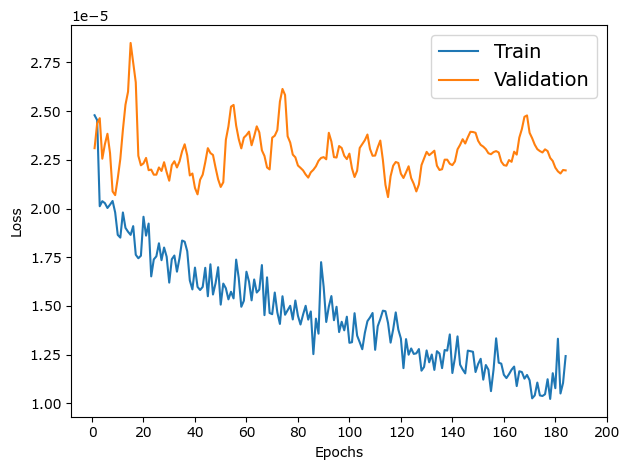

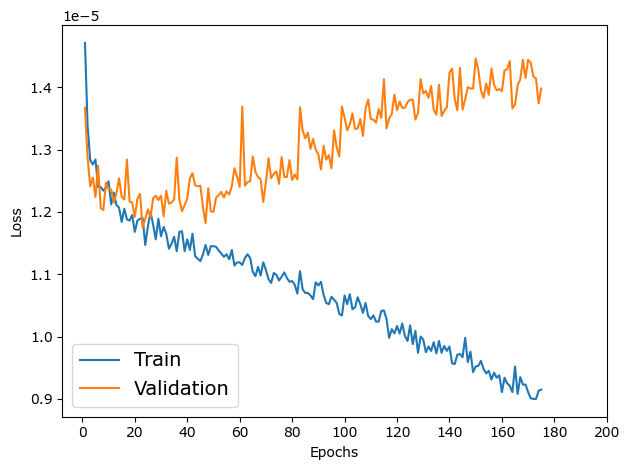

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def graph_plot(file_path, output_path, id):
    epochs = []
    train_cl = []
    val_cl = []
    epochs_i = []
    train_cl_i = []
    val_cl_i = []

    with open(file_path, 'r') as file:
        next(file)
        for line in file:
            # Dividir la línea en elementos usando comas como separadores
            elements = line.strip().split(',')

            # Agregar cada elemento a la lista correspondiente
            epochs.append(int(elements[0]))
            div_train = float(elements[2])
            div_val = float(elements[9])
            train_cl.append(div_train/1000)
            val_cl.append(div_val/1000)

    for i in range(0, len(epochs)):
        if i > 19:
            epochs_i.append(epochs[i])
            train_cl_i.append(train_cl[i])
            val_cl_i.append(val_cl[i])

    plt.plot(epochs, train_cl, label='Train')
    plt.plot(epochs, val_cl, label='Validation')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(fontsize=14)

    #custom_y_ticks = custom_y_ticks = np.arange(1e-5, 1e-4, 5e-6)
    #plt.yticks(custom_y_ticks)

    custom_x_ticks = [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200]
    plt.xticks(custom_x_ticks)
    
    plt.rcParams['font.family'] = 'Verdana'
    plt.tight_layout()
    plt.savefig(output_path + 'cls_loss' + id + '_Final.png', transparent=True, dpi=600)
    plt.show() 

#Change based on the path of the user that is running the code
userpath = 'C:/Users/camiz/'

output_path = userpath + 'Breast_Cancer_Investigation/DetectionModels/lossGraphs/'
input_path =  userpath + 'Breast_Cancer_Investigation/DetectionModels/runs_test/'
input_path_1 = '.pt/test/train/results.csv'
modeln = 'yolo11n'

#INbreast
dataset = 'INbreast'
n_input_path = input_path + dataset + '/' + modeln + input_path_1
graph_plot(n_input_path, output_path, 'nanoIN')

#CBIS
dataset = 'CBIS-DDSM'
n_input_path = input_path + dataset + '/' + modeln + input_path_1
graph_plot(n_input_path, output_path, 'nanoCBIS')

### Performance Metrics (memory and time related) YOLOv11 Averages

In [4]:
import csv
import numpy as np

#Change based on the path of the user that is running the code
userpath = 'C:/Users/camiz/'
model = 'm' #'n', 's'
dataset = 'CBIS-DDSM'
#dataset = 'INbreast'

file_route = userpath + 'Breast_Cancer_Investigation/DetectionModels/runs_test/' +  dataset + '/yolo11' + model + '.pt/performance_metrics_' + dataset + '_final.csv'

# Inicializamos listas
times = []
memories = []

# Leer archivo CSV
with open(file_route, newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        if row['phase'] == 'training':
            try:
                time = float(row['time_seconds'])
                memory = float(row['memory_mb'])
                times.append(time)
                memories.append(memory)
            except ValueError:
                pass  # En caso de que haya algún valor faltante o no convertible

# Calcular promedios
promedio_time = sum(times) / len(times) if times else 0
promedio_memory = sum(memories) / len(memories) if memories else 0

# Calculas desviaciones standard
std_time = np.std(times) if len(times) > 1 else 0
std_memory = np.std(memories) if len(memories) > 1 else 0

# Mostrar resultados
print(f"Average time in seconds (training): {promedio_time:.2f} ({std_time:.2f}) s")
print(f"Average memory in MB (training): {promedio_memory:.2f} ({std_memory:.2f}) MB")


Average time in seconds (training): 5405.33 (565.79) s
Average memory in MB (training): 17753.40 (42.82) MB
